In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math
from models.unet import UNet
from utils import strided_ddim_sample, check_posterior_logic, verify_training_inputs, check_noise_correlation, visualise_loader, make_beta_schedule, periodic_sample_grids, ancestral_sample, plot_ancestral_samples, plot_sampling_norms
from diffusion.diffusion import DiffusionProcess

In [8]:
EPOCHS = 50
L = 1000
BATCH = 128

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


In [10]:
model = UNet()
model.load_state_dict(torch.load("stats_models/lin_model_weights.pth", map_location=device))
model = model.to(device)
model.eval()

diff = DiffusionProcess(1000, device)

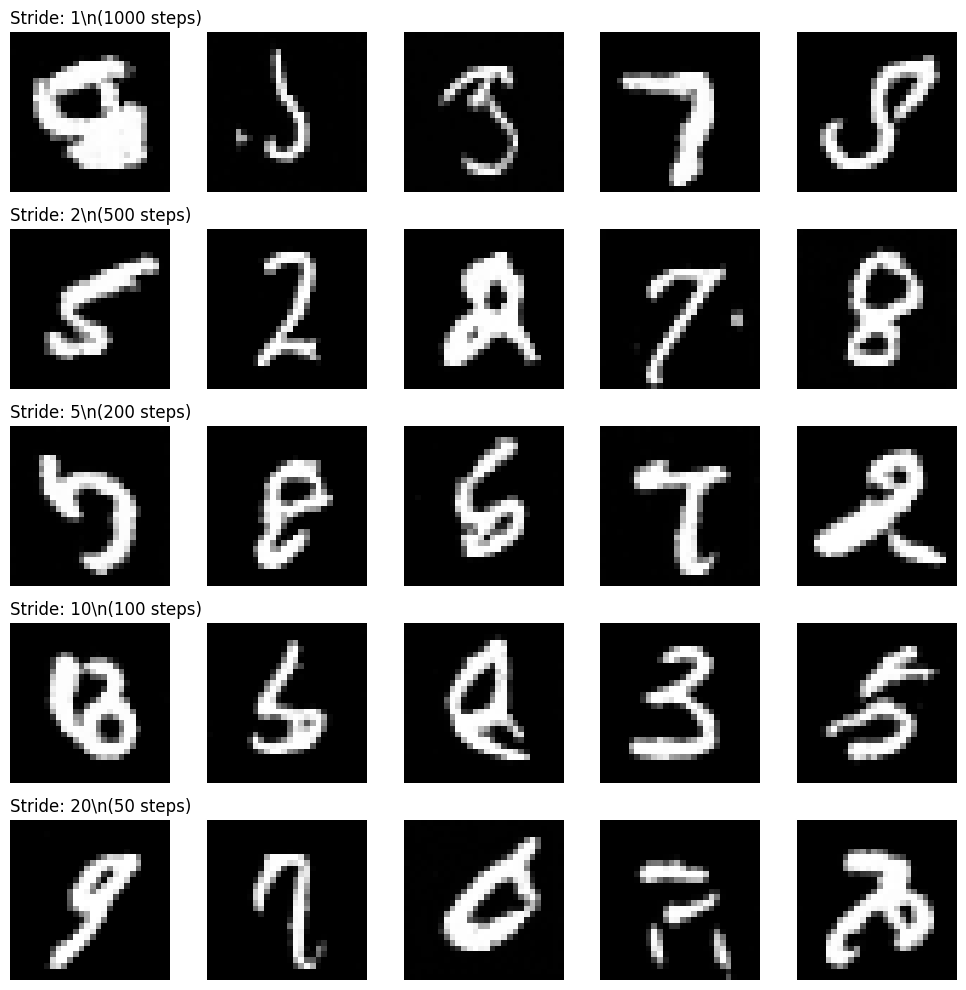

In [12]:
strides_to_test = [1, 2, 5, 10, 20]
count = 5

plt.figure(figsize=(count * 2, len(strides_to_test) * 2))

for row, stride in enumerate(strides_to_test):
    actual_steps = diff.L // stride
    samples = strided_ddim_sample(model, diff, count=count, device=device, stride=stride)
    
    for col in range(count):
        plt.subplot(len(strides_to_test), count, row * count + col + 1)

        img = samples[col].squeeze().detach().cpu().numpy()
        img = (img + 1.0) / 2.0
        img = img.clip(0, 1)

        plt.imshow(img, cmap="gray")
        plt.axis("off")
        
        if col == 0:
            plt.title(f"Stride: {stride}\\n({actual_steps} steps)", loc='left')

plt.tight_layout()
plt.show()